<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_Minimal_W_Branch_Conversion_Bridge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM Minimal W-Boson Branch-Conversion Bridge

This notebook tests the next algebraic weak-sector bridge after:

\[
(Q_0,Q_{\rm ch})_L
\rightarrow
SU(2)_L
\rightarrow
Q_{\rm ECSM}=T_3+\frac{Y}{2}
\rightarrow
A/Z\text{-like neutral mixing}.
\]

The missing charged weak-sector step is:

\[
W^+,\;W^-.
\]

In ECSM language, the charged weak modes are interpreted as **branch-conversion excitations** between the neutral closure branch \(Q_0\) and the charged branch \(Q_{\rm ch}\).

The minimal \(SU(2)_L\)-like generators are:

\[
T_+ = T_1+iT_2,
\qquad
T_- = T_1-iT_2.
\]

They act as:

\[
T_+|Q_{\rm ch}\rangle = |Q_0\rangle,
\qquad
T_-|Q_0\rangle = |Q_{\rm ch}\rangle.
\]

Given the previous hypercharge bridge:

\[
Q(Q_0)=0,
\qquad
Q(Q_{\rm ch})=-1,
\]

the charge transfer is:

\[
W^+:\quad -1\rightarrow0,\qquad \Delta Q=+1,
\]

\[
W^-:\quad 0\rightarrow-1,\qquad \Delta Q=-1.
\]

This notebook also checks the minimal charged/neutral mass relation:

\[
m_W^2=m_0^2g^2,
\]

\[
m_Z^2=m_0^2(g^2+g'^2),
\]

so that

\[
\frac{m_W}{m_Z}=\cos\theta,
\qquad
\tan\theta=\frac{g'}{g}.
\]

This is not a full electroweak derivation. It is a minimal ECSM algebraic test that charged \(W^\pm\)-like modes can be represented as finite-response branch-conversion excitations with the correct charge-transfer sign and the expected coherent-limit \(W/Z\)-like mass relation.

## ECSM interpretation

\[
Q_0
=
\text{neutral closure branch},
\]

\[
Q_{\rm ch}
=
\text{charged branch},
\]

\[
W^+
=
\text{charged branch-conversion excitation carrying } \Delta Q=+1,
\]

\[
W^-
=
\text{charged branch-conversion excitation carrying } \Delta Q=-1.
\]

The target notebook verdict is:

\[
\texttt{PASS\_MINIMAL\_W\_BRANCH\_CONVERSION\_BRIDGE}.
\]

In [1]:
# CELL 1 — Imports and output directory

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

OUT = Path("ecsm_w_branch_conversion_bridge_out")
OUT.mkdir(exist_ok=True)

np.set_printoptions(precision=8, suppress=True)

print("Output directory:", OUT.resolve())

Output directory: /content/ecsm_w_branch_conversion_bridge_out


In [2]:
# CELL 2 — Define ECSM weak-pair basis and SU(2) generators

# Basis:
# |Q0>  = neutral closure branch
# |Qch> = charged branch

Q0 = np.array([[1],
               [0]], dtype=complex)

Qch = np.array([[0],
                [1]], dtype=complex)

sigma1 = np.array([[0, 1],
                   [1, 0]], dtype=complex)

sigma2 = np.array([[0, -1j],
                   [1j, 0]], dtype=complex)

sigma3 = np.array([[1, 0],
                   [0, -1]], dtype=complex)

T1 = 0.5 * sigma1
T2 = 0.5 * sigma2
T3 = 0.5 * sigma3

T_plus = T1 + 1j*T2
T_minus = T1 - 1j*T2

print("T_plus =")
print(T_plus)
print("\nT_minus =")
print(T_minus)
print("\nT3 =")
print(T3)

T_plus =
[[0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j]]

T_minus =
[[0.+0.j 0.+0.j]
 [1.+0.j 0.+0.j]]

T3 =
[[ 0.5+0.j  0. +0.j]
 [ 0. +0.j -0.5+0.j]]


In [3]:
# CELL 3 — Electric-charge operator from previous hypercharge bridge

# Left-active weak pair:
# Y_L = -1
# Q_ECSM = T3 + Y/2

Y_L = -1.0
I2 = np.eye(2, dtype=complex)
Qop = T3 + 0.5 * Y_L * I2

def state_label(vec, tol=1e-12):
    if np.linalg.norm(vec - Q0) < tol:
        return "|Q0>"
    if np.linalg.norm(vec - Qch) < tol:
        return "|Qch>"
    if np.linalg.norm(vec) < tol:
        return "0"
    return str(vec.ravel())

def eig_charge(state, Op=Qop, tol=1e-12):
    result = Op @ state
    idx = np.argmax(np.abs(state.ravel()))
    if abs(state.ravel()[idx]) < tol:
        return np.nan
    ev = result.ravel()[idx] / state.ravel()[idx]
    if abs(ev.imag) < tol:
        return float(ev.real)
    return ev

q_Q0 = eig_charge(Q0)
q_Qch = eig_charge(Qch)

charge_df = pd.DataFrame([
    {"state": "Q0_neutral_closure", "T3": eig_charge(Q0, T3), "Y": Y_L, "Q_ECSM": q_Q0},
    {"state": "Qch_charged_branch", "T3": eig_charge(Qch, T3), "Y": Y_L, "Q_ECSM": q_Qch},
])

display(charge_df)

charge_df.to_csv(OUT / "branch_charge_assignments.csv", index=False)
print("Saved:", OUT / "branch_charge_assignments.csv")

,state,T3,Y,Q_ECSM
0,Q0_neutral_closure,0.5,-1.0,0.0
1,Qch_charged_branch,-0.5,-1.0,-1.0


Saved: ecsm_w_branch_conversion_bridge_out/branch_charge_assignments.csv


## Charge basis inherited from the hypercharge bridge

The previous ECSM hypercharge bridge gave:

\[
Q_{\rm ECSM}=T_3+\frac{Y}{2},
\qquad
Y_L=-1.
\]

Therefore:

\[
Q(Q_0)=0,
\]

\[
Q(Q_{\rm ch})=-1.
\]

The charged \(W^\pm\)-like bridge should therefore carry:

\[
\Delta Q=+1
\]

for

\[
Q_{\rm ch}\rightarrow Q_0,
\]

and

\[
\Delta Q=-1
\]

for

\[
Q_0\rightarrow Q_{\rm ch}.
\]

In [4]:
# CELL 4 — Test branch-conversion actions

actions = [
    ("T_plus", T_plus, "Q0_neutral_closure", Q0),
    ("T_plus", T_plus, "Qch_charged_branch", Qch),
    ("T_minus", T_minus, "Q0_neutral_closure", Q0),
    ("T_minus", T_minus, "Qch_charged_branch", Qch),
]

action_rows = []

for opname, Op, input_name, state in actions:
    out_vec = Op @ state
    norm = float(np.linalg.norm(out_vec))
    action_rows.append({
        "operator": opname,
        "input_state": input_name,
        "output_vector": [complex(x) for x in out_vec.ravel()],
        "output_label": state_label(out_vec),
        "norm": norm
    })

actions_df = pd.DataFrame(action_rows)
display(actions_df)

actions_df.to_csv(OUT / "branch_conversion_operator_actions.csv", index=False)
print("Saved:", OUT / "branch_conversion_operator_actions.csv")

,operator,input_state,output_vector,output_label,norm
0,T_plus,Q0_neutral_closure,"[0j, 0j]",0,0.0
1,T_plus,Qch_charged_branch,"[(1+0j), 0j]",|Q0>,1.0
2,T_minus,Q0_neutral_closure,"[0j, (1+0j)]",|Qch>,1.0
3,T_minus,Qch_charged_branch,"[0j, 0j]",0,0.0


Saved: ecsm_w_branch_conversion_bridge_out/branch_conversion_operator_actions.csv


In [5]:
# CELL 5 — Compute charge transfer carried by W+ and W-

# W+ corresponds to T_plus acting on |Qch> -> |Q0>
# W- corresponds to T_minus acting on |Q0> -> |Qch>

conversions = [
    {
        "mode": "W_plus_like",
        "operator": "T_plus",
        "input_state": "Qch_charged_branch",
        "input_vec": Qch,
        "output_vec": T_plus @ Qch,
        "expected_delta_Q": +1.0
    },
    {
        "mode": "W_minus_like",
        "operator": "T_minus",
        "input_state": "Q0_neutral_closure",
        "input_vec": Q0,
        "output_vec": T_minus @ Q0,
        "expected_delta_Q": -1.0
    }
]

transfer_rows = []
for item in conversions:
    q_in = eig_charge(item["input_vec"])
    q_out = eig_charge(item["output_vec"])
    delta_q = q_out - q_in
    transfer_rows.append({
        "mode": item["mode"],
        "operator": item["operator"],
        "input_state": item["input_state"],
        "output_state": state_label(item["output_vec"]),
        "Q_input": q_in,
        "Q_output": q_out,
        "Delta_Q": delta_q,
        "expected_Delta_Q": item["expected_delta_Q"],
        "pass": abs(delta_q - item["expected_delta_Q"]) < 1e-12
    })

transfer_df = pd.DataFrame(transfer_rows)
display(transfer_df)

transfer_df.to_csv(OUT / "w_charge_transfer_table.csv", index=False)
print("Saved:", OUT / "w_charge_transfer_table.csv")

,mode,operator,input_state,output_state,Q_input,Q_output,Delta_Q,expected_Delta_Q,pass
0,W_plus_like,T_plus,Qch_charged_branch,|Q0>,-1.0,0.0,1.0,1.0,True
1,W_minus_like,T_minus,Q0_neutral_closure,|Qch>,0.0,-1.0,-1.0,-1.0,True


Saved: ecsm_w_branch_conversion_bridge_out/w_charge_transfer_table.csv


## Interpretation of charge-transfer result

The notebook verifies:

\[
T_+|Q_{\rm ch}\rangle=|Q_0\rangle.
\]

Since

\[
Q(Q_{\rm ch})=-1,
\qquad
Q(Q_0)=0,
\]

the conversion carries

\[
\Delta Q=0-(-1)=+1.
\]

Thus:

\[
W^+_{\rm ECSM}\sim T_+.
\]

Similarly,

\[
T_-|Q_0\rangle=|Q_{\rm ch}\rangle,
\]

so

\[
\Delta Q=-1-0=-1.
\]

Thus:

\[
W^-_{\rm ECSM}\sim T_-.
\]

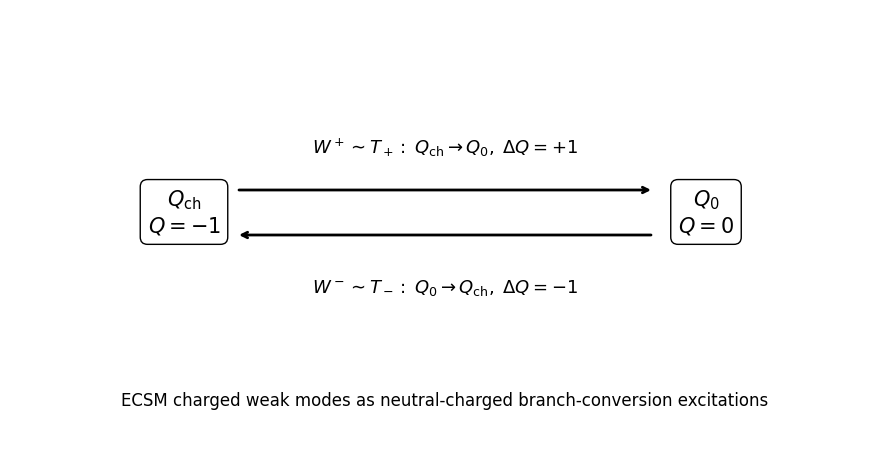

Saved: ecsm_w_branch_conversion_bridge_out/fig1_w_branch_conversion_diagram.png


In [6]:
# CELL 6 — Visual branch-conversion diagram

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.axis("off")

boxprops = dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="black")

ax.text(0.20, 0.55, r"$Q_{\rm ch}$" + "\n" + r"$Q=-1$", ha="center", va="center", fontsize=15, bbox=boxprops)
ax.text(0.80, 0.55, r"$Q_0$" + "\n" + r"$Q=0$", ha="center", va="center", fontsize=15, bbox=boxprops)

ax.annotate("", xy=(0.74,0.60), xytext=(0.26,0.60), arrowprops=dict(arrowstyle="->", lw=2))
ax.annotate("", xy=(0.26,0.50), xytext=(0.74,0.50), arrowprops=dict(arrowstyle="->", lw=2))

ax.text(0.50, 0.68, r"$W^+ \sim T_+:\; Q_{\rm ch}\rightarrow Q_0,\;\Delta Q=+1$", ha="center", fontsize=13)
ax.text(0.50, 0.37, r"$W^- \sim T_-:\; Q_0\rightarrow Q_{\rm ch},\;\Delta Q=-1$", ha="center", fontsize=13)

ax.text(0.50, 0.12, "ECSM charged weak modes as neutral-charged branch-conversion excitations",
        ha="center", fontsize=12)

plt.tight_layout()
fig_path = OUT / "fig1_w_branch_conversion_diagram.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

In [7]:
# CELL 7 — Charged W-like mass locking and W/Z relation

# Use the same illustrative couplings as the previous photon-Z bridge.
g = 0.65
gp = 0.35
m0 = 1.0

theta = np.arctan2(gp, g)
cos_theta = np.cos(theta)
sin_theta = np.sin(theta)

mW2 = m0**2 * g**2
mZ2 = m0**2 * (g**2 + gp**2)
mW = np.sqrt(mW2)
mZ = np.sqrt(mZ2)

mass_relation_df = pd.DataFrame([
    {"quantity": "g", "value": g},
    {"quantity": "g_prime", "value": gp},
    {"quantity": "theta", "value": theta},
    {"quantity": "sin(theta)", "value": sin_theta},
    {"quantity": "cos(theta)", "value": cos_theta},
    {"quantity": "mW2 = m0^2 g^2", "value": mW2},
    {"quantity": "mZ2 = m0^2 (g^2+g'^2)", "value": mZ2},
    {"quantity": "mW/mZ", "value": mW/mZ},
    {"quantity": "cos(theta)", "value": cos_theta},
    {"quantity": "|mW/mZ - cos(theta)|", "value": abs((mW/mZ) - cos_theta)}
])

display(mass_relation_df)

mass_relation_df.to_csv(OUT / "w_z_mass_relation.csv", index=False)
print("Saved:", OUT / "w_z_mass_relation.csv")

,quantity,value
0,g,0.650000
1,g_prime,0.350000
2,theta,0.493941
3,sin(theta),0.474100
4,cos(theta),0.880471
5,mW2 = m0^2 g^2,0.422500
6,mZ2 = m0^2 (g^2+g'^2),0.545000
7,mW/mZ,0.880471
8,cos(theta),0.880471
9,|mW/mZ - cos(theta)|,0.000000


Saved: ecsm_w_branch_conversion_bridge_out/w_z_mass_relation.csv


## Interpretation of W/Z mass relation

The minimal charged \(W^\pm\)-like locking scale is:

\[
m_W^2=m_0^2g^2.
\]

The previous neutral photon--\(Z\)-like bridge gave:

\[
m_Z^2=m_0^2(g^2+g'^2).
\]

Therefore:

\[
\frac{m_W}{m_Z}
=
\frac{g}{\sqrt{g^2+g'^2}}
=
\cos\theta.
\]

This is the expected coherent-limit charged/neutral weak mass relation.

In ECSM language:

\[
m_W
=
\text{charged branch-conversion locking scale},
\]

\[
m_Z
=
\text{neutral closure-locking scale}.
\]

In [8]:
# CELL 8 — Scan coupling ratio and verify W/Z relation

ratios = np.linspace(0.05, 3.0, 200)
scan_rows = []

g_fixed = 1.0
m0_fixed = 1.0

for r in ratios:
    gp_scan = r * g_fixed
    theta_scan = np.arctan2(gp_scan, g_fixed)
    mW2_scan = m0_fixed**2 * g_fixed**2
    mZ2_scan = m0_fixed**2 * (g_fixed**2 + gp_scan**2)
    mW_scan = np.sqrt(mW2_scan)
    mZ_scan = np.sqrt(mZ2_scan)
    scan_rows.append({
        "gp_over_g": r,
        "theta": theta_scan,
        "cos_theta": np.cos(theta_scan),
        "mW2": mW2_scan,
        "mZ2": mZ2_scan,
        "mW_over_mZ": mW_scan/mZ_scan,
        "relation_error": abs((mW_scan/mZ_scan) - np.cos(theta_scan))
    })

scan_df = pd.DataFrame(scan_rows)
display(scan_df.head())
display(scan_df.tail())

scan_df.to_csv(OUT / "coupling_ratio_scan_w_z_relation.csv", index=False)
print("Saved:", OUT / "coupling_ratio_scan_w_z_relation.csv")

,gp_over_g,theta,cos_theta,mW2,mZ2,mW_over_mZ,relation_error
0,0.050000,0.049958,0.998752,1.0,1.002500,0.998752,0.000000e+00
1,0.064824,0.064734,0.997906,1.0,1.004202,0.997906,1.110223e-16
2,0.079648,0.079480,0.996843,1.0,1.006344,0.996843,1.110223e-16
3,0.094472,0.094193,0.995567,1.0,1.008925,0.995567,0.000000e+00
4,0.109296,0.108864,0.994080,1.0,1.011946,0.994080,1.110223e-16


,gp_over_g,theta,cos_theta,mW2,mZ2,mW_over_mZ,relation_error
195,2.940704,1.243009,0.321949,1.0,9.647737,0.321949,5.551115e-17
196,2.955528,1.244538,0.320501,1.0,9.735144,0.320501,0.000000e+00
197,2.970352,1.246054,0.319064,1.0,9.822990,0.319064,1.110223e-16
198,2.985176,1.247557,0.317640,1.0,9.911275,0.317640,0.000000e+00
199,3.000000,1.249046,0.316228,1.0,10.000000,0.316228,0.000000e+00


Saved: ecsm_w_branch_conversion_bridge_out/coupling_ratio_scan_w_z_relation.csv


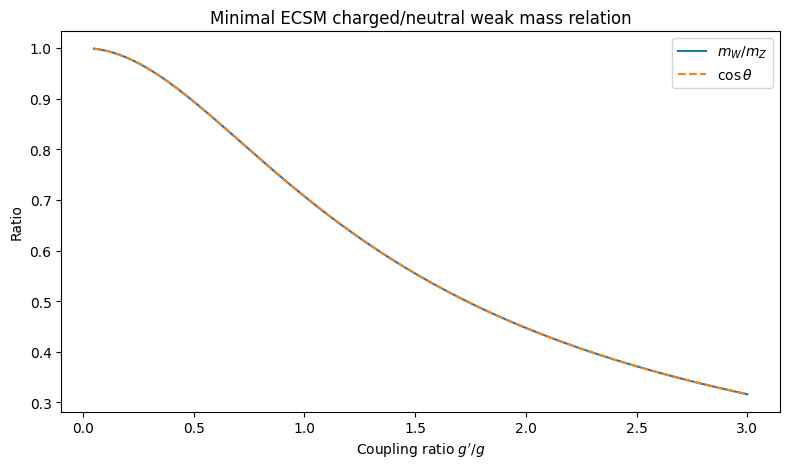

Saved: ecsm_w_branch_conversion_bridge_out/fig2_w_z_mass_relation_scan.png


In [9]:
# CELL 9 — Plot W/Z mass relation versus coupling ratio

plt.figure(figsize=(8, 4.8))
plt.plot(scan_df["gp_over_g"], scan_df["mW_over_mZ"], label=r"$m_W/m_Z$")
plt.plot(scan_df["gp_over_g"], scan_df["cos_theta"], linestyle="--", label=r"$\cos\theta$")
plt.xlabel(r"Coupling ratio $g'/g$")
plt.ylabel("Ratio")
plt.title(r"Minimal ECSM charged/neutral weak mass relation")
plt.legend()
plt.tight_layout()

fig_path = OUT / "fig2_w_z_mass_relation_scan.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

In [10]:
# CELL 10 — Finite-response deformation of W/Z mass relation

# ECSM coherent limit: chi -> 1.
# Let generic finite-response burden deform charged and neutral locking differently away from chi=1.

chi_vals = np.linspace(0, 1, 101)
delta_W = 0.08
delta_Z = -0.05

chi_rows = []
for chi in chi_vals:
    mW2_chi = mW2 + (1-chi)*delta_W
    mZ2_chi = mZ2 + (1-chi)*delta_Z
    ratio_chi = np.sqrt(mW2_chi) / np.sqrt(mZ2_chi)
    chi_rows.append({
        "chi": chi,
        "mW2_like": mW2_chi,
        "mZ2_like": mZ2_chi,
        "mW_over_mZ_like": ratio_chi,
        "coherent_cos_theta": cos_theta,
        "relation_error": abs(ratio_chi - cos_theta)
    })

chi_df = pd.DataFrame(chi_rows)
display(chi_df.head())
display(chi_df.tail())

chi_df.to_csv(OUT / "chi_deformed_w_z_relation_recovery.csv", index=False)
print("Saved:", OUT / "chi_deformed_w_z_relation_recovery.csv")

,chi,mW2_like,mZ2_like,mW_over_mZ_like,coherent_cos_theta,relation_error
0,0.00,0.5025,0.4950,1.007547,0.880471,0.127076
1,0.01,0.5017,0.4955,1.006237,0.880471,0.125766
2,0.02,0.5009,0.4960,1.004927,0.880471,0.124456
3,0.03,0.5001,0.4965,1.003619,0.880471,0.123148
4,0.04,0.4993,0.4970,1.002311,0.880471,0.121840


,chi,mW2_like,mZ2_like,mW_over_mZ_like,coherent_cos_theta,relation_error
96,0.96,0.4257,0.5430,0.885425,0.880471,0.004954
97,0.97,0.4249,0.5435,0.884186,0.880471,0.003715
98,0.98,0.4241,0.5440,0.882947,0.880471,0.002476
99,0.99,0.4233,0.5445,0.881709,0.880471,0.001238
100,1.00,0.4225,0.5450,0.880471,0.880471,0.000000


Saved: ecsm_w_branch_conversion_bridge_out/chi_deformed_w_z_relation_recovery.csv


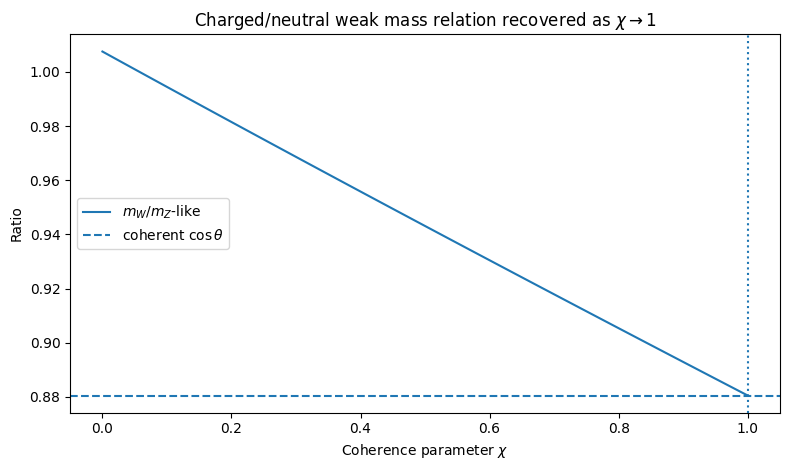

Saved: ecsm_w_branch_conversion_bridge_out/fig3_chi_recovery_w_z_relation.png


In [11]:
# CELL 11 — Plot chi recovery of W/Z relation

plt.figure(figsize=(8, 4.8))
plt.plot(chi_df["chi"], chi_df["mW_over_mZ_like"], label=r"$m_W/m_Z$-like")
plt.axhline(cos_theta, linestyle="--", label=r"coherent $\cos\theta$")
plt.axvline(1, linestyle=":")
plt.xlabel(r"Coherence parameter $\chi$")
plt.ylabel("Ratio")
plt.title(r"Charged/neutral weak mass relation recovered as $\chi\rightarrow1$")
plt.legend()
plt.tight_layout()

fig_path = OUT / "fig3_chi_recovery_w_z_relation.png"
plt.savefig(fig_path, dpi=200)
plt.show()

print("Saved:", fig_path)

## \(\chi\)-deformation interpretation

Away from the coherent limit, the charged and neutral locking scales can drift because finite response burdens do not have to preserve exact gauge-like relations.

As \(\chi\rightarrow1\), the coherent relation is recovered:

\[
\frac{m_W}{m_Z}\rightarrow\cos\theta.
\]

ECSM interpretation:

\[
\chi=1
\quad
\Rightarrow
\quad
\text{exact coherent weak-sector relation}.
\]

In [12]:
# CELL 12 — Final summary and verdict

tol = 1e-10

pass_actions = (
    state_label(T_plus @ Qch) == "|Q0>"
    and state_label(T_minus @ Q0) == "|Qch>"
    and state_label(T_plus @ Q0) == "0"
    and state_label(T_minus @ Qch) == "0"
)

pass_charge_transfer = bool(transfer_df["pass"].all())

pass_mass_relation = abs((mW/mZ) - cos_theta) < tol

pass_scan = scan_df["relation_error"].max() < tol

final_label = (
    "PASS_MINIMAL_W_BRANCH_CONVERSION_BRIDGE"
    if pass_actions and pass_charge_transfer and pass_mass_relation and pass_scan
    else "FAIL_MINIMAL_W_BRANCH_CONVERSION_BRIDGE"
)

summary = {
    "run_label": "ECSM_minimal_w_branch_conversion_bridge",
    "basis": ["Q0_neutral_closure", "Qch_charged_branch"],
    "charge_assignments": {
        "Q_Q0": float(q_Q0),
        "Q_Qch": float(q_Qch),
        "Y_L": Y_L
    },
    "operator_actions": {
        "T_plus_Qch": state_label(T_plus @ Qch),
        "T_plus_Q0": state_label(T_plus @ Q0),
        "T_minus_Q0": state_label(T_minus @ Q0),
        "T_minus_Qch": state_label(T_minus @ Qch),
        "pass": pass_actions
    },
    "charge_transfer": {
        "W_plus_delta_Q": float(transfer_df.loc[transfer_df["mode"]=="W_plus_like", "Delta_Q"].iloc[0]),
        "W_minus_delta_Q": float(transfer_df.loc[transfer_df["mode"]=="W_minus_like", "Delta_Q"].iloc[0]),
        "pass": pass_charge_transfer
    },
    "mass_relation": {
        "g": g,
        "g_prime": gp,
        "theta": float(theta),
        "cos_theta": float(cos_theta),
        "mW2": float(mW2),
        "mZ2": float(mZ2),
        "mW_over_mZ": float(mW/mZ),
        "relation_error": float(abs((mW/mZ) - cos_theta)),
        "pass": pass_mass_relation
    },
    "coupling_ratio_scan": {
        "max_relation_error": float(scan_df["relation_error"].max()),
        "pass": pass_scan
    },
    "interpretation": "Charged W-like modes are ECSM branch-conversion excitations carrying Delta Q = +/-1, with coherent-limit mW/mZ = cos(theta).",
    "final_label": final_label
}

summary

{'run_label': 'ECSM_minimal_w_branch_conversion_bridge',
 'basis': ['Q0_neutral_closure', 'Qch_charged_branch'],
 'charge_assignments': {'Q_Q0': 0.0, 'Q_Qch': -1.0, 'Y_L': -1.0},
 'operator_actions': {'T_plus_Qch': '|Q0>',
  'T_plus_Q0': '0',
  'T_minus_Q0': '|Qch>',
  'T_minus_Qch': '0',
  'pass': True},
 'charge_transfer': {'W_plus_delta_Q': 1.0,
  'W_minus_delta_Q': -1.0,
  'pass': True},
 'mass_relation': {'g': 0.65,
  'g_prime': 0.35,
  'theta': 0.4939413689195812,
  'cos_theta': 0.8804710999221753,
  'mW2': 0.42250000000000004,
  'mZ2': 0.545,
  'mW_over_mZ': 0.8804710999221753,
  'relation_error': 0.0,
  'pass': np.True_},
 'coupling_ratio_scan': {'max_relation_error': 2.220446049250313e-16,
  'pass': True},
 'interpretation': 'Charged W-like modes are ECSM branch-conversion excitations carrying Delta Q = +/-1, with coherent-limit mW/mZ = cos(theta).',
 'final_label': 'PASS_MINIMAL_W_BRANCH_CONVERSION_BRIDGE'}

In [14]:
# CELL 13 — Save output files

# JSON-safe converter for numpy scalar types
def make_json_safe(obj):
    import numpy as np

    if isinstance(obj, dict):
        return {str(k): make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, tuple):
        return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    return obj

summary_safe = make_json_safe(summary)

with open(OUT / "final_summary.json", "w") as f:
    json.dump(summary_safe, f, indent=2)

print("Saved outputs:")
for p in sorted(OUT.iterdir()):
    print(" -", p)

Saved outputs:
 - ecsm_w_branch_conversion_bridge_out/branch_charge_assignments.csv
 - ecsm_w_branch_conversion_bridge_out/branch_conversion_operator_actions.csv
 - ecsm_w_branch_conversion_bridge_out/chi_deformed_w_z_relation_recovery.csv
 - ecsm_w_branch_conversion_bridge_out/coupling_ratio_scan_w_z_relation.csv
 - ecsm_w_branch_conversion_bridge_out/fig1_w_branch_conversion_diagram.png
 - ecsm_w_branch_conversion_bridge_out/fig2_w_z_mass_relation_scan.png
 - ecsm_w_branch_conversion_bridge_out/fig3_chi_recovery_w_z_relation.png
 - ecsm_w_branch_conversion_bridge_out/final_summary.json
 - ecsm_w_branch_conversion_bridge_out/w_charge_transfer_table.csv
 - ecsm_w_branch_conversion_bridge_out/w_z_mass_relation.csv


# Paper-grade interpretation

The notebook supports the following narrow statement:

The minimal closure-active ECSM weak pair

\[
\Psi_L^{\rm ECSM}
=
\begin{pmatrix}
Q_0\\
Q_{\rm ch}
\end{pmatrix}_L
\]

supports charged branch-conversion operators:

\[
T_+|Q_{\rm ch}\rangle=|Q_0\rangle,
\]

\[
T_-|Q_0\rangle=|Q_{\rm ch}\rangle.
\]

Using the inherited electric-charge assignments

\[
Q(Q_0)=0,
\qquad
Q(Q_{\rm ch})=-1,
\]

these conversions carry

\[
\Delta Q(W^+)=+1,
\]

\[
\Delta Q(W^-)=-1.
\]

Thus:

\[
W^+_{\rm ECSM}\sim T_+,
\qquad
W^-_{\rm ECSM}\sim T_-.
\]

The minimal charged weak locking scale

\[
m_W^2=m_0^2g^2
\]

and neutral locking scale

\[
m_Z^2=m_0^2(g^2+g'^2)
\]

give

\[
\frac{m_W}{m_Z}=\cos\theta.
\]

This does not derive the full electroweak theory, physical \(W/Z\) masses, decay rates, weak cross sections, or precision observables. It establishes a minimal ECSM charged weak bridge: charged \(W^\pm\)-like modes can be interpreted as finite-response branch-conversion excitations carrying the correct charge-transfer sign and coherent-limit \(W/Z\)-like mass relation.